# Random Walk implementation (DeepWalk)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import networkx as nx
import numpy as np
import random
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [2]:
def drawGraphWithWalk(G,walk):
 pos=nx.kamada_kawai_layout(G)
 c,k=[],0
 for u,v in G.edges:
  found=False
  for k in range(len(walk)-1):
   if (walk[k]==u and walk[k+1]==v) or (walk[k]==v and walk[k+1]==u):
    found=True
    break
  if found: c.append('red')
  else: c.append('blue')
 nx.draw(G,pos,with_labels=True,edge_color=c)
 print(walk)

[2, 28, 31, 28, 2, 3, 2]


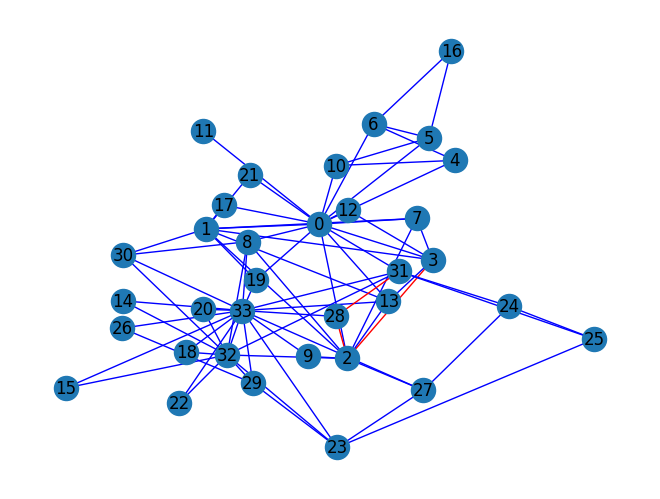

In [3]:
G = nx.karate_club_graph()

def generate_random_walks(G, num_walks=10, walk_length=80):
    walks = []
    nodes = list(G.nodes())
    for _ in range(num_walks):
        random.shuffle(nodes)
        node=nodes[0]
        walk = [node]
        for _ in range(walk_length - 1):
                curr = walk[-1]
                neighbors = list(G.neighbors(curr))
                if neighbors: walk.append(random.choice(neighbors))
                else: walk.append(curr)
        walks.append(walk)
    return walks

walks = generate_random_walks(G, num_walks=1, walk_length=7)
drawGraphWithWalk(G,walks[0])


In [4]:
def generate_training_pairs(nodes, walks, window_size=1, num_neg_samples=5):
    vocab_size, pairs = len(nodes), []
    for walk in walks:
        for i, center in enumerate(walk):
            start = max(0, i - window_size)
            end = min(len(walk), i + window_size + 1)
            for j in range(start, end):
                if i != j:
                    pos_ctx = walk[j]
                    pairs.append((center, pos_ctx, 1))  # Positive pair
                    for _ in range(num_neg_samples):
                        neg_ctx = random.randint(0, vocab_size - 1)
                        while neg_ctx == center or neg_ctx == pos_ctx:
                            neg_ctx = random.randint(0, vocab_size - 1)
                        pairs.append((center, neg_ctx, 0))  # Negative pair
    return window_size+num_neg_samples,pairs
batch,pairs=generate_training_pairs(list(G.nodes()), walks)
print(batch)

6


In [5]:
print(pairs[0],pairs[1:batch])

(2, 28, 1) [(2, 27, 0), (2, 14, 0), (2, 10, 0), (2, 33, 0), (2, 11, 0)]


In [6]:
class GraphEmbedder(nn.Module):
    def __init__(self, num_nodes, embedding_dim):
        super(GraphEmbedder, self).__init__()
        self.embeddings = nn.Embedding(num_nodes, embedding_dim)
    def forward(self, node_ids):
        return self.embeddings(node_ids)

In [7]:
def contrastive_loss(pos_scores, neg_scores):
    loss=0
    if len(pos_scores) > 0: loss += -torch.log(torch.sigmoid(pos_scores) + 1e-15).sum()
    if len(neg_scores) > 0: loss += torch.log(torch.sigmoid(neg_scores) + 1e-15).sum()
    return loss

In [8]:
num_nodes = G.number_of_nodes()
num_nodes

34

In [9]:
walks = generate_random_walks(G, num_walks=7, walk_length=5)
walks

[[24, 31, 33, 32, 14],
 [19, 0, 3, 0, 3],
 [26, 29, 26, 29, 32],
 [25, 23, 29, 26, 29],
 [1, 2, 32, 33, 15],
 [2, 28, 33, 8, 30],
 [29, 26, 29, 23, 27]]

In [10]:
nodes=list(G.nodes())
batch_size,pairs = generate_training_pairs(nodes, walks)
batch_size

6

In [11]:
pairs = np.array(pairs)  # (N, 3): [center, context, label]
centers = torch.tensor(pairs[:, 0], dtype=torch.long).to(device)
contexts = torch.tensor(pairs[:, 1], dtype=torch.long).to(device)
labels = torch.tensor(pairs[:, 2], dtype=torch.float).to(device)

In [12]:
embedding_dim,lr=3,1e-2
model = GraphEmbedder(num_nodes, embedding_dim).to(device)
optimizer = optim.SGD(model.parameters(), lr=lr)

In [13]:
model.train()
num_epochs=1
for epoch in range(num_epochs):
    total_loss = 0.0
    for i in range(0, len(pairs), batch_size):
        batch_centers = centers[i:i+batch_size]
        batch_contexts = contexts[i:i+batch_size]
        batch_labels = labels[i:i+batch_size]
        optimizer.zero_grad()
        center_embeds = model(batch_centers)  # (B, d)
        context_embeds = model(batch_contexts)  # (B, d)
        print('c:',center_embeds)
        print('ct:',context_embeds)

        scores = torch.sum(center_embeds * context_embeds, dim=1)  # (B,)
        print('c*ct:',scores)

        pos_scores = scores[batch_labels == 1]
        neg_scores = scores[batch_labels == 0]
        print('pos:',pos_scores)
        print('neg:',neg_scores)

        loss = contrastive_loss(pos_scores,neg_scores)
        print('loss:',loss)
        break
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss:.4f}")


c: tensor([[1.1196, 0.3398, 0.2091],
        [1.1196, 0.3398, 0.2091],
        [1.1196, 0.3398, 0.2091],
        [1.1196, 0.3398, 0.2091],
        [1.1196, 0.3398, 0.2091],
        [1.1196, 0.3398, 0.2091]], device='cuda:0',
       grad_fn=<EmbeddingBackward0>)
ct: tensor([[ 1.2663, -1.9770, -1.6856],
        [-0.8018,  0.1875, -0.1405],
        [ 0.5608,  0.4022, -0.0862],
        [-0.2575, -0.1950, -1.8631],
        [ 0.1052, -0.0782, -0.3086],
        [ 0.1169,  0.7694,  1.0236]], device='cuda:0',
       grad_fn=<EmbeddingBackward0>)
c*ct: tensor([ 0.3935, -0.8634,  0.7466, -0.7441,  0.0267,  0.6063], device='cuda:0',
       grad_fn=<SumBackward1>)
pos: tensor([0.3935], device='cuda:0', grad_fn=<IndexBackward0>)
neg: tensor([-0.8634,  0.7466, -0.7441,  0.0267,  0.6063], device='cuda:0',
       grad_fn=<IndexBackward0>)
loss: tensor(-3.3356, device='cuda:0', grad_fn=<AddBackward0>)
Epoch 1/1, Loss: 0.0000


In [14]:
embedding_dim,lr=3,1e-2
model = GraphEmbedder(num_nodes, embedding_dim).to(device)
optimizer = optim.SGD(model.parameters(), lr=lr)

walks = generate_random_walks(G, num_walks=1000, walk_length=10)
nodes=list(G.nodes())
batch_size,pairs = generate_training_pairs(nodes, walks)
pairs = np.array(pairs)  # (N, 3): [center, context, label]
centers = torch.tensor(pairs[:, 0], dtype=torch.long).to(device)
contexts = torch.tensor(pairs[:, 1], dtype=torch.long).to(device)
labels = torch.tensor(pairs[:, 2], dtype=torch.float).to(device)


model.train()
num_epochs=10
for epoch in range(num_epochs):
    total_loss = 0.0
    for i in range(0, len(pairs), batch_size):
        batch_centers = centers[i:i+batch_size]
        batch_contexts = contexts[i:i+batch_size]
        batch_labels = labels[i:i+batch_size]
        optimizer.zero_grad()
        center_embeds = model(batch_centers)  # (B, d)
        context_embeds = model(batch_contexts)  # (B, d)
        scores = torch.sum(center_embeds * context_embeds, dim=1)  # (B,)
        pos_scores = scores[batch_labels == 1]
        neg_scores = scores[batch_labels == 0]
        loss = contrastive_loss(pos_scores,neg_scores)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss:.4f}")


Epoch 1/10, Loss: -1262230.8703
Epoch 2/10, Loss: -1357709.9673
Epoch 3/10, Loss: -1357713.8633
Epoch 4/10, Loss: -1357715.4359
Epoch 5/10, Loss: -1357716.2994
Epoch 6/10, Loss: -1357716.8491
Epoch 7/10, Loss: -1357717.2295
Epoch 8/10, Loss: -1357717.5135
Epoch 9/10, Loss: -1357717.7338
Epoch 10/10, Loss: -1357717.9132


In [15]:
model.eval()
with torch.no_grad():
  embeddings = model.embeddings.weight.cpu().data.numpy()

In [16]:
print("Embedding for node 1:", embeddings[1])
print("Shape:", embeddings[1].shape)

Embedding for node 1: [-2.460219  -6.977857  -1.6583754]
Shape: (3,)


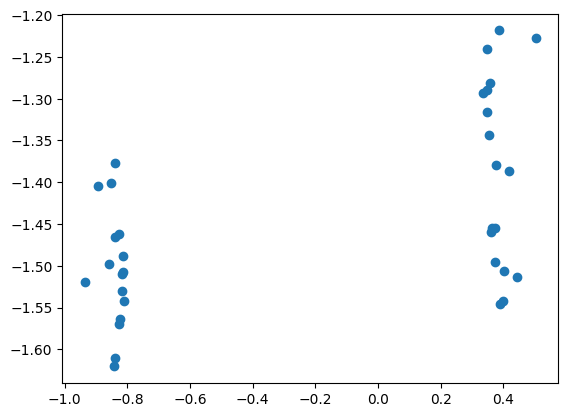

In [17]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
tr=TSNE(n_components=2)
ne=tr.fit_transform(embeddings)
plt.scatter(ne[:,0],ne[:,1])

Text(0.5, 1.0, '3')

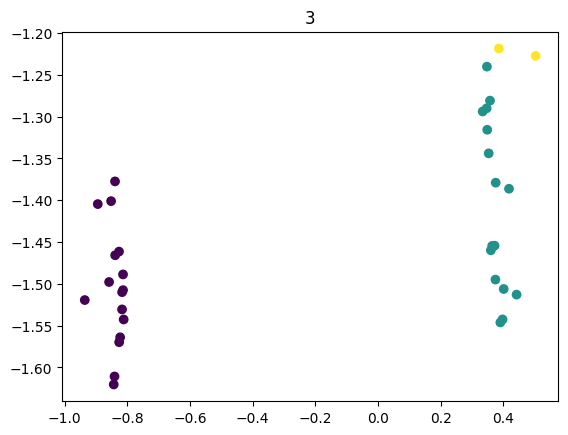

In [18]:
from sklearn.mixture import GaussianMixture
gm_opt,gm_opt_bic,gm_opt_c,gm_opt_n=[],1e100,[],-1
for n in range(1,20):
 clf=GaussianMixture(n_components=n)
 c=clf.fit_predict(ne)
 bic=clf.bic(ne)
 if bic<gm_opt_bic:
  gm_opt=clf
  gm_opt_bic=bic
  gm_opt_c=c
  gm_opt_n=n
plt.scatter(ne[:,0],ne[:,1],c=gm_opt_c)
plt.title(str(gm_opt_n))

[2 1 0 0 1 1 1 0 1 1 1 0 1 0 0 0 1 1 1 1 0 2 1 1 0 0 0 1 1 0 0 0 0 0]


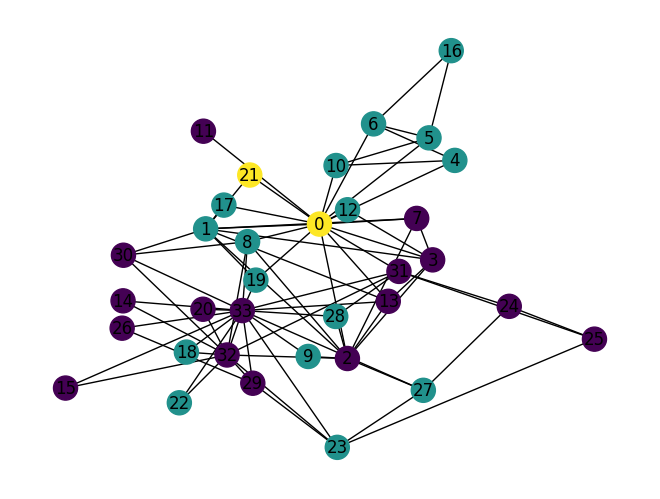

In [19]:
def drawGraphWithEmb(G,c):
 pos=nx.kamada_kawai_layout(G)
 nx.draw(G,pos,with_labels=True,node_color=c)
 print(c)
drawGraphWithEmb(G,gm_opt_c)

Text(0.5, 1.0, '2')

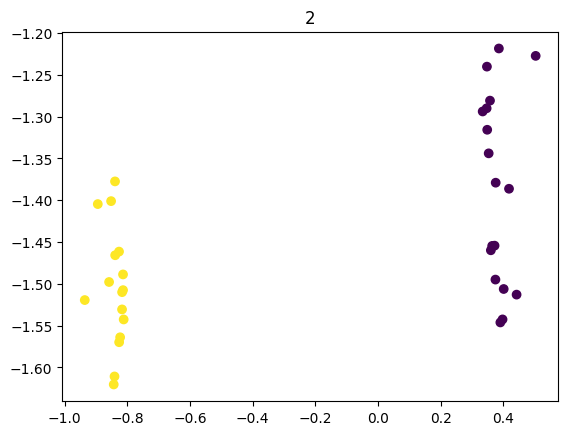

In [20]:
n=2
clf=GaussianMixture(n_components=n)
c=clf.fit_predict(ne)
plt.scatter(ne[:,0],ne[:,1],c=c)
plt.title(str(n))

[0 0 1 1 0 0 0 1 0 0 0 1 0 1 1 1 0 0 0 0 1 0 0 0 1 1 1 0 0 1 1 1 1 1]


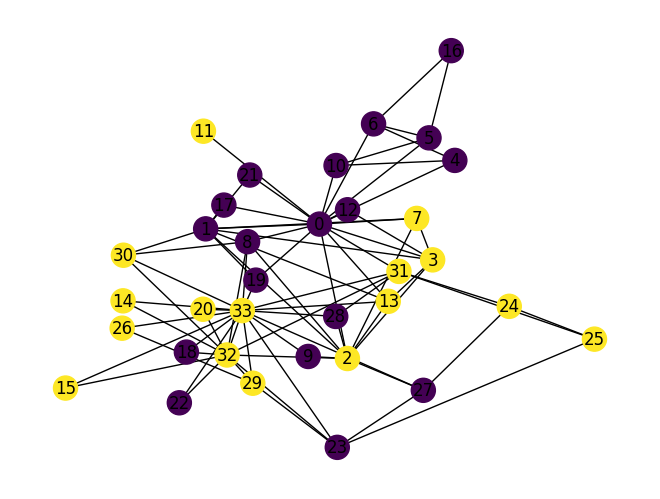

In [21]:
drawGraphWithEmb(G,c)

Text(0.5, 1.0, '2')

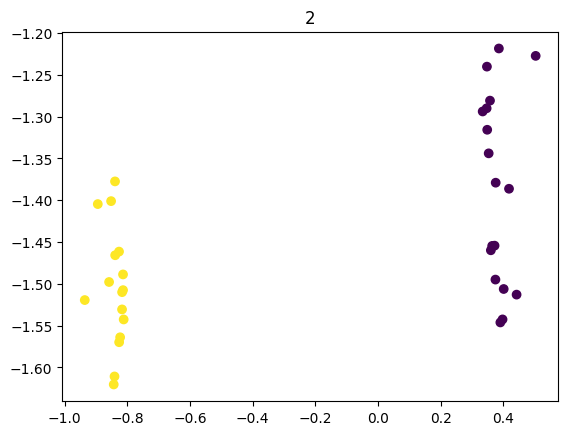

In [22]:
n=2
clf=GaussianMixture(n_components=n)
c=clf.fit_predict(embeddings)
plt.scatter(ne[:,0],ne[:,1],c=c)
plt.title(str(n))

[0 0 1 1 0 0 0 1 0 0 0 1 0 1 1 1 0 0 0 0 1 0 0 0 1 1 1 0 0 1 1 1 1 1]


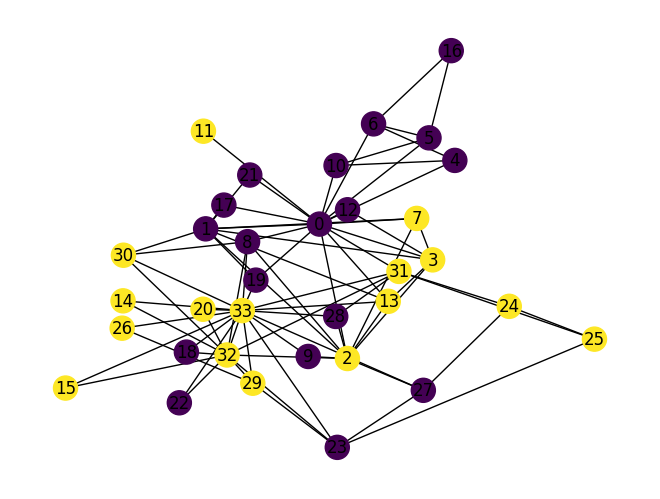

In [23]:
drawGraphWithEmb(G,c)